Տարածության մեջ տրված է` 

$$
\vec r(u) = (u^2 + 1)\vec i + (u^3 + 2)\vec j + (2u - 3)\vec k
$$

ուղղորդ կորը որտեղ

$$
0 \le u \le 10, \qquad -\frac{\pi}{3} \le v \le \frac{\pi}{3}:
$$

Տուփաձև մակերևույթը բաղկացած է երեք նիստերից, այսինքն`

$$
K = 3
$$ 

(կանոնավոր եռանկյուն),

$$
k = 1,2,3
$$

իսկ անկյունային տեղաշարժը՝

$$
\varphi = \frac{\pi}{K}:
$$

$R_0(u)$-ն շրջանագծի շառավղի բանաձևն է, որը կարող է լինել հաստատուն և փոփոխական:

ա)

$$
R_0(u) = 5
$$

բ)

$$
R_0(u) = \frac{u^3 + 2}{u^2 + 1}
$$

Պահանջվում է կառուցել մակերևույթի

$$
\rho_1(u,v), \rho_2(u,v), \rho_3(u,v)
$$ 

նիստերի պարամետրական հավասարումները`

$$
\vec{\rho}_k(u,v)=
\vec r(u)+
\frac{R_0(u)\cos\varphi}{\cos v}
\left(
\cos(v+2\varphi k)\,\vec e_0(u)+
\sin(v+2\varphi k)\,\vec g_0(u)
\right),
$$
որտեղ $\vec e_0(u)$ և $\vec g_0(u)$ միավոր վեկտորները ընտրվում են հետևյալ բանաձևերով`

$$
\vec e_0(u)=
\frac{(\vec r'(u)\times\vec r''(u))\times\vec r'(u)}
{\left|\vec r'(u)\times\vec r''(u)\right|\cdot\left|\vec r'(u)\right|},
$$

$$
\vec g_0(u)=
\frac{\vec r'(u)\times \vec r''(u)}
{\left|\vec r'(u)\times \vec r''(u)\right|}:
$$

ինչպես նաև կառուցել տուփաձև մակերևույթը որպես այդ նիստերի միավորում՝

$$
S = \rho_1(u,v) \cup \rho_2(u,v) \cup \rho_3(u,v),
$$

և իրականացնել դրանց գրաֆիկական պատկերումը:

In [3]:
import numpy as np
import sympy as sp
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [4]:
u, v = sp.symbols('u v', real=True)

r_u = sp.Matrix([u**2 + 1, u**3 + 2, 2*u - 3])
r_prime = sp.diff(r_u, u)
r_double_prime = sp.diff(r_prime, u)

cross_vec = r_prime.cross(r_double_prime)
norm_cross = sp.sqrt(cross_vec.dot(cross_vec))
g0_u = cross_vec / norm_cross

numerator_e0 = cross_vec.cross(r_prime)
norm_r_prime = sp.sqrt(r_prime.dot(r_prime))
e0_u = numerator_e0 / (norm_cross * norm_r_prime)

In [5]:
K = 3
phi = sp.pi / K

In [6]:
def build_rhos(R0_expr):
    rhos_local = []
    for k in [1, 2, 3]:
        rho_k = r_u + (R0_expr * sp.cos(phi) / sp.cos(v)) * (
            sp.cos(v + 2 * phi * k) * e0_u +
            sp.sin(v + 2 * phi * k) * g0_u
        )
        rhos_local.append(rho_k)
    for i, rho in enumerate(rhos_local, start=1):
      print(f"\nρ_{i}(u,v) =")
      sp.pprint(rho)
    return rhos_local

In [7]:
def lambdify_rhos(rhos_local):
    funcs = []
    for rho in rhos_local:
        fx = sp.lambdify((u, v), rho[0], "numpy")
        fy = sp.lambdify((u, v), rho[1], "numpy")
        fz = sp.lambdify((u, v), rho[2], "numpy")
        funcs.append((fx, fy, fz))
    return funcs

In [8]:
def plot_three_surfaces(rho_funcs, U, V, title):
    fig = make_subplots(
        rows=1, cols=3,
        specs=[[{'type': 'surface'}] * 3],
        subplot_titles=("ρ₁(u,v)", "ρ₂(u,v)", "ρ₃(u,v)")
    )

    colors = ["Viridis", "Plasma", "Inferno"]

    for i, ((fx, fy, fz), cs) in enumerate(zip(rho_funcs, colors), start=1):
        X = fx(U, V)
        Y = fy(U, V)
        Z = fz(U, V)
        fig.add_surface(x=X, y=Y, z=Z, colorscale=cs, showscale=False, row=1, col=i)

    fig.update_layout(title=title, width=1200, height=500)
    fig.show()

In [9]:
def plot_union(rho_funcs, U, V, title):
    fig = go.Figure()
    colors = ["Viridis", "Plasma", "Inferno"]

    for (fx, fy, fz), cs in zip(rho_funcs, colors):
        fig.add_surface(
            x=fx(U, V), y=fy(U, V), z=fz(U, V),
            opacity=0.65, colorscale=cs, showscale=False
        )

    fig.update_layout(
        title=title,
        width=850,
        height=700,
        scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z"),
    )
    fig.show()

In [10]:
u_vals = np.linspace(0.0, 10.0, 140)
v_vals = np.linspace(-np.pi/3, np.pi/3, 140)
U, V = np.meshgrid(u_vals, v_vals)

In [11]:
print("r(u) =")
sp.pprint(r_u)

print("\nr'(u) =")
sp.pprint(r_prime)

print("\nr''(u) =")
sp.pprint(r_double_prime)

print("\ng₀(u) =")
sp.pprint(g0_u)

print("\ne₀(u) =")
sp.pprint(e0_u)

r(u) =
⎡ 2     ⎤
⎢u  + 1 ⎥
⎢       ⎥
⎢ 3     ⎥
⎢u  + 2 ⎥
⎢       ⎥
⎣2⋅u - 3⎦

r'(u) =
⎡2⋅u ⎤
⎢    ⎥
⎢   2⎥
⎢3⋅u ⎥
⎢    ⎥
⎣ 2  ⎦

r''(u) =
⎡ 2 ⎤
⎢   ⎥
⎢6⋅u⎥
⎢   ⎥
⎣ 0 ⎦

g₀(u) =
⎡         -12⋅u          ⎤
⎢────────────────────────⎥
⎢   _____________________⎥
⎢  ╱     4        2      ⎥
⎢╲╱  36⋅u  + 144⋅u  + 16 ⎥
⎢                        ⎥
⎢           4            ⎥
⎢────────────────────────⎥
⎢   _____________________⎥
⎢  ╱     4        2      ⎥
⎢╲╱  36⋅u  + 144⋅u  + 16 ⎥
⎢                        ⎥
⎢             2          ⎥
⎢          6⋅u           ⎥
⎢────────────────────────⎥
⎢   _____________________⎥
⎢  ╱     4        2      ⎥
⎣╲╱  36⋅u  + 144⋅u  + 16 ⎦

e₀(u) =
⎡                          4                  ⎤
⎢                  8 - 18⋅u                   ⎥
⎢─────────────────────────────────────────────⎥
⎢   _________________    _____________________⎥
⎢  ╱    4      2        ╱     4        2      ⎥
⎢╲╱  9⋅u  + 4⋅u  + 4 ⋅╲╱  36⋅u  + 144⋅u  + 16 ⎥
⎢                                       

In [12]:
R0_const = sp.Integer(5)
rhos_a = build_rhos(R0_const)
rho_funcs_a = lambdify_rhos(rhos_a)


ρ_1(u,v) =
⎡       ⎛              ⎛    π⎞                   ⎛        4⎞    ⎛    π⎞        ↪
⎢       ⎜      12⋅u⋅cos⎜v + ─⎟                   ⎝8 - 18⋅u ⎠⋅sin⎜v + ─⎟        ↪
⎢       ⎜              ⎝    6⎠                                  ⎝    6⎠        ↪
⎢     5⋅⎜- ──────────────────────── - ──────────────────────────────────────── ↪
⎢       ⎜     _____________________      _________________    ________________ ↪
⎢       ⎜    ╱     4        2           ╱    4      2        ╱     4        2  ↪
⎢ 2     ⎝  ╲╱  36⋅u  + 144⋅u  + 16    ╲╱  9⋅u  + 4⋅u  + 4 ⋅╲╱  36⋅u  + 144⋅u   ↪
⎢u  + ──────────────────────────────────────────────────────────────────────── ↪
⎢                                        2⋅cos(v)                              ↪
⎢                                                                              ↪
⎢       ⎛            ⎛    3       ⎞    ⎛    π⎞                        ⎛    π⎞  ↪
⎢       ⎜            ⎝12⋅u  + 24⋅u⎠⋅sin⎜v + ─⎟                   4⋅cos⎜v + ─⎟  ↪
⎢       ⎜       

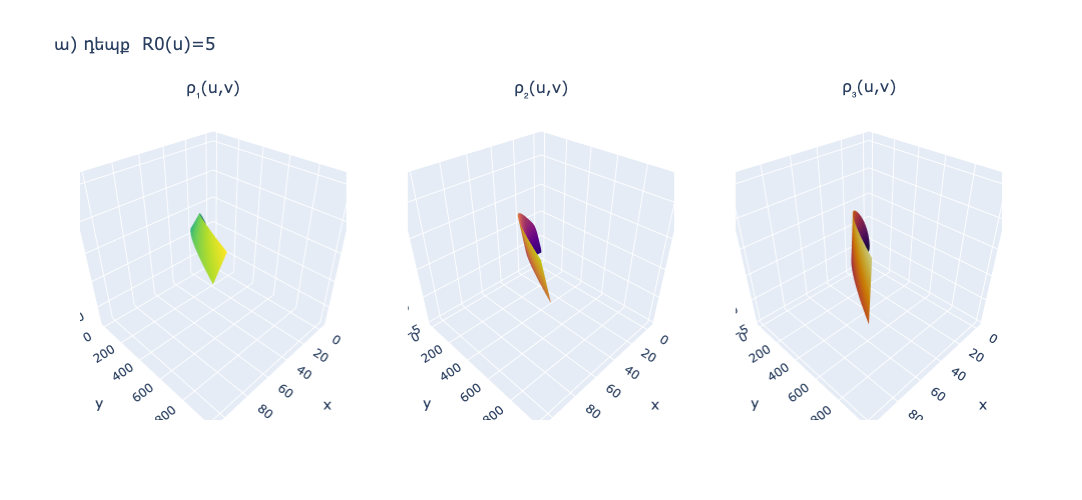

In [13]:
plot_three_surfaces(rho_funcs_a, U, V, "ա) դեպք  R0(u)=5")

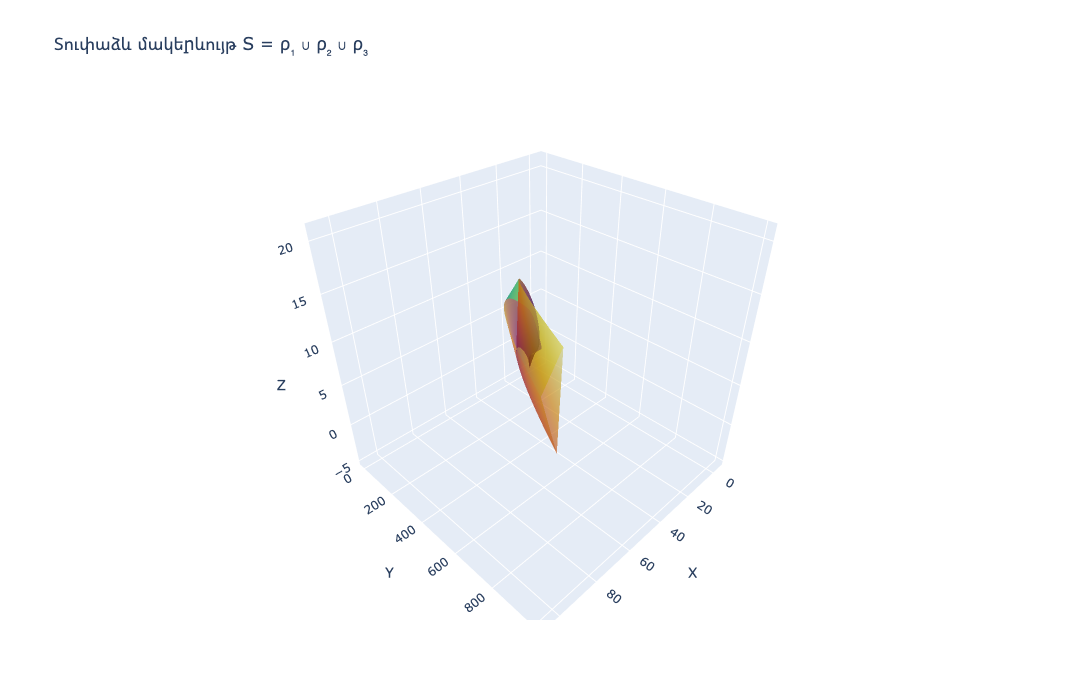

In [14]:
plot_union(rho_funcs_a, U, V, "Տուփաձև մակերևույթ S = ρ₁ ∪ ρ₂ ∪ ρ₃")

In [15]:
R0_var = (u**3 + 2) / (u**2 + 1)
rhos_b = build_rhos(R0_var)
rho_funcs_b = lambdify_rhos(rhos_b)


ρ_1(u,v) =
⎡                  ⎛              ⎛    π⎞                   ⎛        4⎞    ⎛   ↪
⎢                  ⎜      12⋅u⋅cos⎜v + ─⎟                   ⎝8 - 18⋅u ⎠⋅sin⎜v  ↪
⎢         ⎛ 3    ⎞ ⎜              ⎝    6⎠                                  ⎝   ↪
⎢         ⎝u  + 2⎠⋅⎜- ──────────────────────── - ───────────────────────────── ↪
⎢                  ⎜     _____________________      _________________    _____ ↪
⎢                  ⎜    ╱     4        2           ╱    4      2        ╱      ↪
⎢ 2                ⎝  ╲╱  36⋅u  + 144⋅u  + 16    ╲╱  9⋅u  + 4⋅u  + 4 ⋅╲╱  36⋅u ↪
⎢u  + 1 + ──────────────────────────────────────────────────────────────────── ↪
⎢                                             ⎛ 2    ⎞                         ↪
⎢                                           2⋅⎝u  + 1⎠⋅cos(v)                  ↪
⎢                                                                              ↪
⎢                  ⎛            ⎛    3       ⎞    ⎛    π⎞                      ↪
⎢               

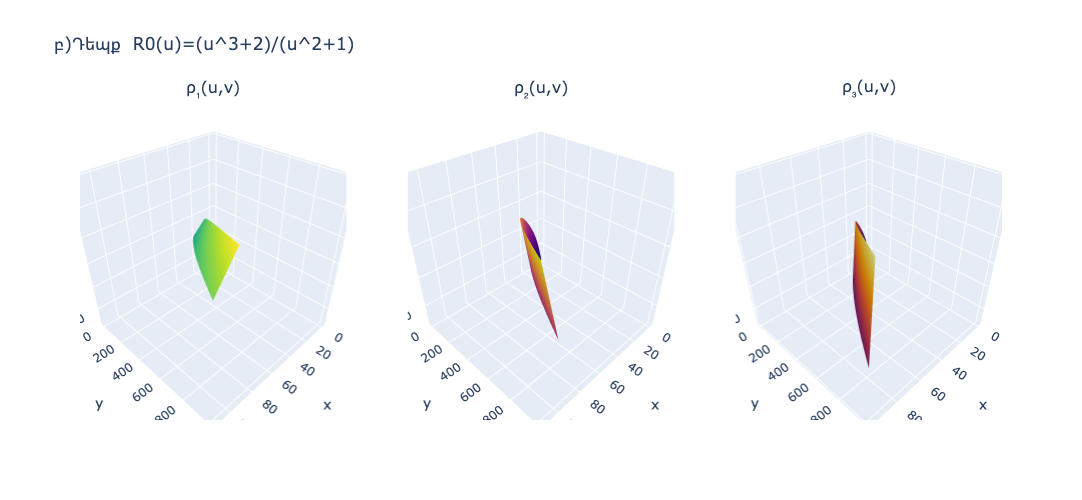

In [16]:
plot_three_surfaces(rho_funcs_b, U, V, "բ)Դեպք  R0(u)=(u^3+2)/(u^2+1) ")

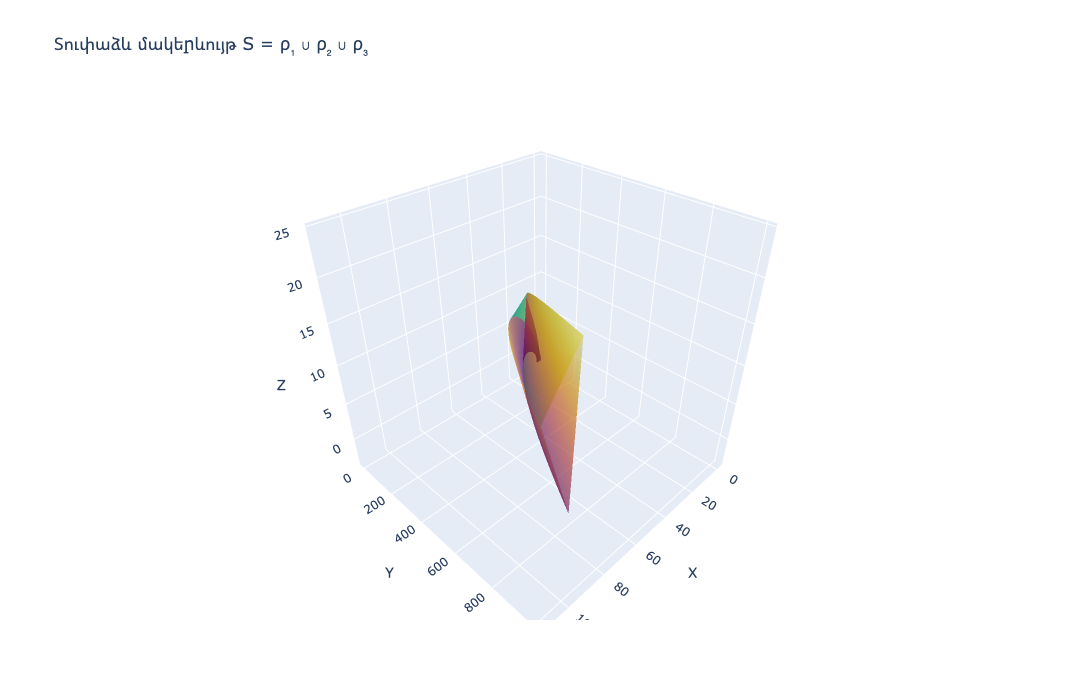

In [17]:
plot_union(rho_funcs_b, U, V, "Տուփաձև մակերևույթ S = ρ₁ ∪ ρ₂ ∪ ρ₃")